Utilizando dispositivo: cuda

Iniciando el entrenamiento...
Época [1/2], Paso [300/938], Pérdida: 0.3084
Época [1/2], Paso [600/938], Pérdida: 0.1243
Época [1/2], Paso [900/938], Pérdida: 0.0997
Época [2/2], Paso [300/938], Pérdida: 0.0708
Época [2/2], Paso [600/938], Pérdida: 0.0786
Época [2/2], Paso [900/938], Pérdida: 0.0742
¡Entrenamiento finalizado!

Exactitud (Accuracy) del modelo en las 10,000 imágenes de prueba: 97.83%


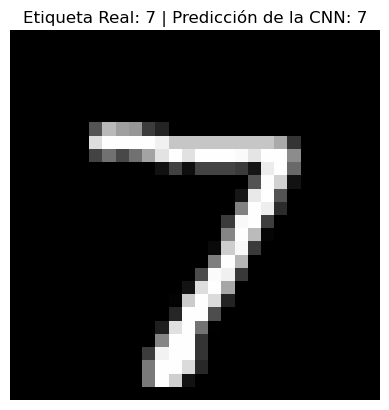

In [1]:
# =====================================================================
# PRÁCTICA: Mi Primera Red Convolucional (CNN) Básica con MNIST
# =====================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 1. Configurar el dispositivo (Usar GPU si está disponible para ir más rápido)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Utilizando dispositivo: {device}")

# 2. Descargar y Preparar el Dataset MNIST
# Transformación básica: Convertir las imágenes a Tensores
transform = transforms.ToTensor()

# Descargamos el set de entrenamiento y el de prueba
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Creamos los DataLoaders para manejar la imagen por lotes (Batches de 64 imágenes)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

# =====================================================================

# 3. Definición de la Arquitectura CNN Básica
# =====================================================================
class CNNBasica(nn.Module):
    def __init__(self):
        super(CNNBasica, self).__init__()

        # Capa Convolucional: Entrada=1 canal (gris), Salida=16 filtros, Kernel=3x3, Padding=1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        # Capa Max Pooling: Reduce el tamaño a la mitad (de 28x28 a 14x14)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Capa Totalmente Conectada (Linear):
        # Entrada: 16 canales * 14 de alto * 14 de ancho = 3136 características aplanadas
        # Salida: 10 clases (números del 0 al 9)
        self.fc = nn.Linear(16 * 14 * 14, 10)

    def forward(self, x):
        # Flujo de la arquitectura: Convolución -> ReLU -> Pooling
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        # Aplanar el mapa de características para poder pasarlo a la capa lineal
        x = x.view(x.size(0), -1)

        # Clasificación final
        x = self.fc(x)
        return x

# Instanciar el modelo y pasarlo al dispositivo (CPU/GPU)
model = CNNBasica().to(device)

# 4. Definir Función de Pérdida (Loss) y Optimitzador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# =====================================================================
# 5. Entrenamiento del Modelo (Solo 2 Épocas para demostración rápida)
# =====================================================================
num_epochs = 2
print("\nIniciando el entrenamiento...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Paso hacia adelante (Forward pass)
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Paso hacia atrás y optimización (Backward pass)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if (i+1) % 300 == 0:
            print(f"Época [{epoch+1}/{num_epochs}], Paso [{i+1}/{len(train_loader)}], Pérdida: {running_loss/300:.4f}")
            running_loss = 0.0

print("¡Entrenamiento finalizado!")

# =====================================================================
# 6. Evaluación en el Set de Prueba e Inferencia Visual
# =====================================================================
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'\nExactitud (Accuracy) del modelo en las 10,000 imágenes de prueba: {100 * correct / total:.2f}%')

# 7. Mostrar una predicción en pantalla
imagenes_muestra, etiquetas_muestra = next(iter(test_loader))
con_prediccion = model(imagenes_muestra.to(device))
_, prediccion = torch.max(con_prediccion, 1)

# Dibujar el primer elemento del lote
plt.imshow(imagenes_muestra[0].squeeze(), cmap='gray')
plt.title(f"Etiqueta Real: {etiquetas_muestra[0].item()} | Predicción de la CNN: {prediccion[0].item()}")
plt.axis('off')
plt.show()

In [ ]:
## PRueba de imagen

# 1. Conectar Google Colab con Google Drive
from google.colab import drive
from PIL import Image
drive.mount('/content/drive')

# Asegúrate de subir una imagen (por ejemplo, 'mi_imagen.jpg') a tu Drive.
# Modifica la siguiente ruta con la ubicación real de tu archivo en Drive.
ruta_imagen_drive = '/content/drive/MyDrive/8_2.jpg'

try:
    # 3. Cargar la imagen desde Drive y convertirla a escala de grises
    # Nota didáctica: Usamos escala de grises (1 solo canal) para facilitar la comprensión matemática de la convolución.
    imagen_pil = Image.open(ruta_imagen_drive).convert('L')
    print("¡Imagen cargada correctamente desde Google Drive!")
except FileNotFoundError:
    print(f"Error: No se encontró ningún archivo en la ruta: {ruta_imagen_drive}")
    print("Por favor, verifica el nombre y la extensión del archivo en tu Google Drive.")

transformacion = transforms.ToTensor()
imagen_tensor = transformacion(imagen_pil).unsqueeze(0) 

outputs = model( imagen_tensor.to(device) )
_, predicted = torch.max(outputs.data, 1)

# Dibujar el primer elemento del lote
plt.imshow(imagen_tensor.squeeze(), cmap='gray')
plt.title(f"Etiqueta Real: Predicción de la CNN: {predicted[0].item()}")
plt.axis('off')
plt.show()

MessageError: Failed to issue request POST https://colab.research.google.com/tun/m/credentials-propagation/gpu-t4-s-kkb-usw4b2-3bfnepesuzzer?authtype=dfs_ephemeral&version=2&dryrun=true&propagate=true&record=false&authuser=0: Not Found
Response body: 
<!DOCTYPE html>
<html lang=en>
  <meta charset=utf-8>
  <meta name=viewport content="initial-scale=1, minimum-scale=1, width=device-width">
  <title>Error 404 (Not Found)!!1</title>
  <style>
    *{margin:0;padding:0}html,code{font:15px/22px arial,sans-serif}html{background:#fff;color:#222;padding:15px}body{margin:7% auto 0;max-width:390px;min-height:180px;padding:30px 0 15px}* > body{background:url(//www.google.com/images/errors/robot.png) 100% 5px no-repeat;padding-right:205px}p{margin:11px 0 22px;overflow:hidden}ins{color:#777;text-decoration:none}a img{border:0}@media screen and (max-width:772px){body{background:none;margin-top:0;max-width:none;padding-right:0}}#logo{background:url(//www.google.com/images/logos/errorpage/error_logo-15

: 